In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import kagglehub
# Download latest version
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")
print("Path to dataset files:", path)
df=pd.read_csv("/Users/sarthak/.cache/kagglehub/datasets/yasserh/housing-prices-dataset/versions/1/Housing.csv")
df.info()
df.describe()

Path to dataset files: /Users/sarthak/.cache/kagglehub/datasets/yasserh/housing-prices-dataset/versions/1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


/var/folders/rj/yzdtrlc11gz0vt7njkp70yf80000gn/T/ipykernel_7542/1133838448.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cols]=df[cols].replace({'yes':1,'no':0})
/var/folders/rj/yzdtrlc11gz0vt7njkp70yf80000gn/T/ipykernel_7542/1133838448.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['furnishingstatus']=df['furnishingstatus'].replace({'unfurnished':0,'semi-furnished':1,'furnished':2})


rmse: 0.23927805603017574
[0.66793028 0.14529107 0.41389731 0.31239387 0.13761518 0.0512762
 0.09697961 0.18132505 0.17033309 0.14049486 0.13143235 0.09186565]


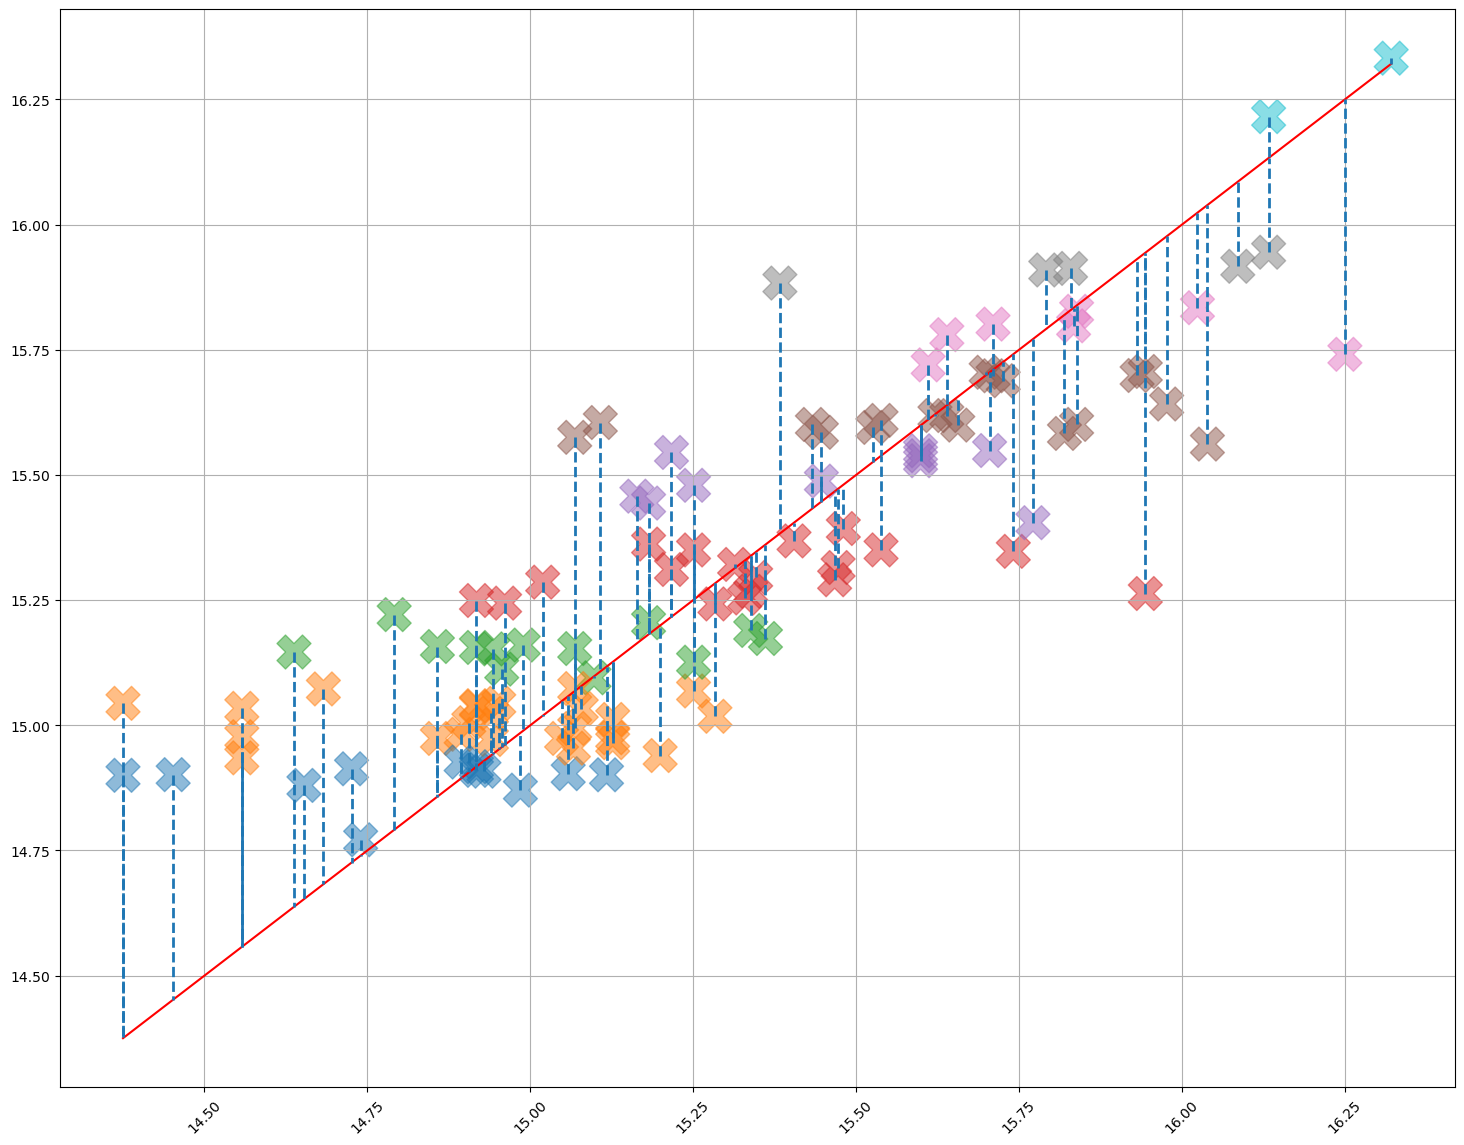

      Actual     predicted
0  4690000.0  3.887793e+06
1  3010000.0  3.818808e+06
2  5110000.0  5.323759e+06
3  3143000.0  4.172506e+06
4  7420000.0  5.855546e+06


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
df=df.sort_values(by='price').reset_index(drop=True)
cols=['mainroad','basement','stories','guestroom','hotwaterheating','airconditioning','prefarea']
df[cols]=df[cols].replace({'yes':1,'no':0})

df['furnishingstatus']=df['furnishingstatus'].replace({'unfurnished':0,'semi-furnished':1,'furnished':2})


X=df.drop(columns=['price'])
y=np.log(df['price'])
features=X.columns


X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
mean_squared_error_1=mean_squared_error(y_test,y_pred)
print('rmse:',np.sqrt(mean_squared_error_1))
fig,ax=plt.subplots(figsize=(18,14))
importance=model.coef_.flatten()



print(importance)
ax.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],color='red')
ax.scatter(y_test,y_pred,c=y_pred,cmap='tab10',s=600,alpha=0.5,marker='X')
ax.vlines(y_test,y_pred,y_test,linestyles='--',linewidth=2)
#ax.fill_between([y_test.min(),y_test.max()],[y_test.min(),y_test.max()])
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


y_test=np.exp(y_test)
y_pred=np.exp(y_pred)
results=pd.DataFrame({'Actual':y_test,'predicted':y_pred})
print(results.head().reset_index(drop=True))